# Projet Zoidberg

## Experiments v3

### Importation des scripts pythons

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# On remonte d'un dossier pour s'échapper de 01_exploration, et encore d'un autre pour s'échapper de notebooks
# afin de pointer vers le dossier 'src' à la racine de ton projet
sys.path.append(os.path.abspath("../../src"))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import models

# Ensuite on adapte les imports pour utiliser les nouveaux sous-dossiers :
# from visualization.data_exploration import plot_roc_curve, plot_binary_confusion_matrix
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

root = Path.cwd().resolve()
src_paths = [
    root / "src",
    root.parent / "src",
    root.parent.parent / "src",
]
for p in src_paths:
    if p.exists():
        sys.path.insert(0, str(p))
        break
else:
    raise FileNotFoundError("Impossible de trouver le dossier 'src' dans les chemins attendus.")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import models

from visualization.data_exploration import (
    visualize_batch,
    visualize_specific_class,
    show_class_distribution,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_multiclass_roc,
    plot_binary_confusion_matrix,
)

from models.cnn_model import build_cnn
from models.transfert_model import build_efficientnet

from data.data_loader import create_data_generator

from models.cnn_model import build_cnn
from models.transfert_model import build_efficientnet

from data.data_loader import create_data_generator


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'sklearn.metrics'

## Récupération des données 

### Fichier binaire ( */chest_Xray_old* )
### Fichier catégorie ( */chest_Xray* )

## Classification binaire - **Normal** ou **Pneumonie**

* * *

## 🎯 Objectif 

```
Le but est classé des images Xray médicale pour trouver 
- Poumon normal 
- Poumon atteint d'une pneumonie
```

* * *

## Modèle utilisé 

- Backbone : **EfficientNetB0** (_ImageNet pre-trained_)
- Fine-tuning : last 20 layers unfrozen
- input size : 224x224
- output : Sigmoid (_probabilité binaire_)

* * *

## Méthode d'entrainement 

1. Stage 1 - Extraction des caractéristiques
    - Base model frozen
    - 3 epochs
    - Learning rate : 1e-4
2. Stage 2 - Fine Tuning
    - Last 20 layers unfrozen
    - Learning rate : to 1e-5
    - 45 total epochs
    - Gradual convergence observed

* * *

## 📊 Final Performance (Test Set)

- Précision : 97%

- Précision (Pneumonie): 0.88%

- Recall (Pneumonie): 0.97%

- F1-score (Pneumonie): 0.92%

- Faux négatifs : 10 cas

* * *

## 🧠 Interpretation

- Le modèle atteint une haute sensibilité (recall), ce qui signifie que peu de cas de pneumonie sont manqués.
- La précision reste correcte, ce qui indique un taux de fauses alarmes limités.
- Le fait de fine-tuning réduit les faux négatifs (de 81 -> 36 -> 10).
- L'entrainement est stable sans d'overfitting

* * *

## 🏁 Conclusion

- On peut dire que le modèle binaire EfficientNet est stable et validé.

- Cette version est gelé comme nom : 

```
Binary EfficientNet V2 - Fine-Tuned Model
```

- Il va permettre d'être utilisé comme : 
    - Une base cliniquement interpretable
    - Une référence pour comparer le modèle multi-class

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE=(224, 224)
BACTH=32

def create_binary_generators(data_dir):

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_gen_binary = train_datagen.flow_from_directory(
        f"{data_dir}/train",
        target_size=IMG_SIZE,
        batch_size=BACTH,
        class_mode="binary",
        subset="training"
    )

    val_gen_binary = train_datagen.flow_from_directory(
        f"{data_dir}/train",
        target_size=IMG_SIZE,
        batch_size=BACTH,
        class_mode="binary",
        subset="validation"
    )

    test_gen_binary = test_datagen.flow_from_directory(
        f"{data_dir}/test",
        target_size=IMG_SIZE,
        batch_size=BACTH,
        class_mode="binary",
        shuffle=False
    )

    return train_gen_binary, val_gen_binary, test_gen_binary

In [9]:
train_gen_binary, val_gen_binary, test_gen_binary = create_binary_generators("../data/raw/chest_Xray_old")
train_gen_binary.class_indices

Found 4180 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.
Found 1973 images belonging to 2 classes.


{'NORMAL': 0, 'PNEUMONIA': 1}

In [11]:
y_train_binary = np.where(train_gen_binary.classes == 1, 0, 1)
y_val_binary = np.where(val_gen_binary.classes == 1, 0, 1)
y_test_binary = np.where(test_gen_binary.classes == 1, 0, 1)

print(train_gen_binary.class_indices)
print(np.bincount(train_gen_binary.classes))
print(np.bincount(val_gen_binary.classes))

NameError: name 'np' is not defined

### Mise en place du modèle

In [6]:
from keras import layers, models
from keras.applications import EfficientNetB0
from keras.optimizers import Adam

def build_binary_efficientnet():

    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    for layer in base_model.layers[:-20]:
        layer.trainable=False

    model.compile(
        optimizer=Adam(1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()

    return model

### Entrainement du modèle

In [ ]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model_efficientnet_binary.keras",
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    mode="min"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
train_gen, val_gen, test_gen = create_binary_generators("../../data/raw/chest_Xray_old")

model = build_binary_efficientnet()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=2,
    callbacks=[early_stopping, checkpoint]
)

Found 4180 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.
Found 1973 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,352,241 (5.16 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6133 - loss: 0.6572
Epoch 1: val_loss improved from None to 0.51223, saving model to best_model_efficientnet_binary.keras

Epoch 1: finished saving model to best_model_efficientnet_binary.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.7089 - loss: 0.5918 - val_accuracy: 0.8391 - val_loss: 0.5122
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8418 - loss: 0.4599
Epoch 2: val_loss improved from 0.51223 to 0.39103, saving model to best_model_efficientnet_binary.keras

Epoch 2: finished saving model to best_model_efficientnet_binary.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 65s 493ms/step - accuracy: 0.8629 - loss: 0.4293 - val_accuracy: 0.8669 - val_loss: 0.3910
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8909 - loss: 0.3630
Epoch 3: val_loss improved from 0.39103 to 0.31381, saving model to best_model_efficientnet_binary.keras

Epoch 3: finished saving model to best_model

### Prédiction du modèle et résultats

62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 696ms/step
2026-04-30 11:50:37.927127
Modèle enregistré


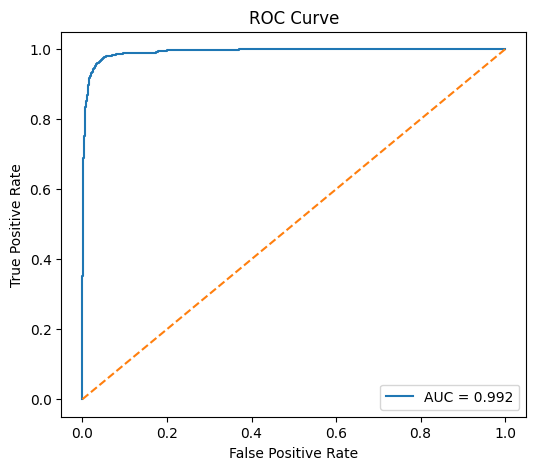


AUC Score: 0.992


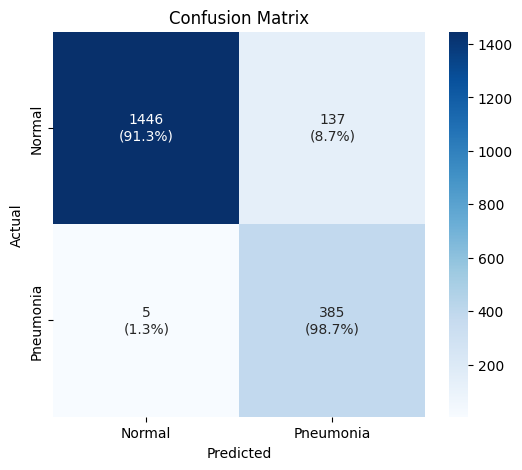


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1583
           1       0.74      0.99      0.84       390

    accuracy                           0.93      1973
   macro avg       0.87      0.95      0.90      1973
weighted avg       0.95      0.93      0.93      1973



In [8]:
import datetime

best_threshold = 0.5

y_true = test_gen_binary.classes
y_pred_probs = model.predict(test_gen_binary)
y_pred = (y_pred_probs > best_threshold).astype(int)

print(datetime.datetime.now())
print("Modèle enregistré")
model.save("efficientnet_binary_stage1.keras")

plot_roc_curve(y_true, y_pred_probs, best_threshold)

plot_binary_confusion_matrix(y_true, y_pred)

### Recharger le meilleur modèle

``` text/plain
model_load = models.load_model("efficientnet_binary_stage1.keras")
```

Rechargement du modèle...
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 471ms/step
(1973, 1)


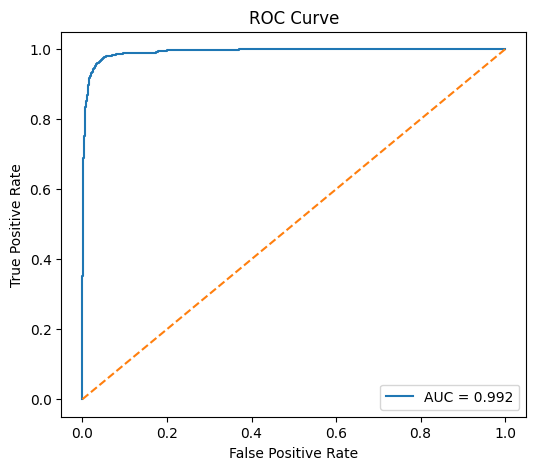


AUC Score: 0.992


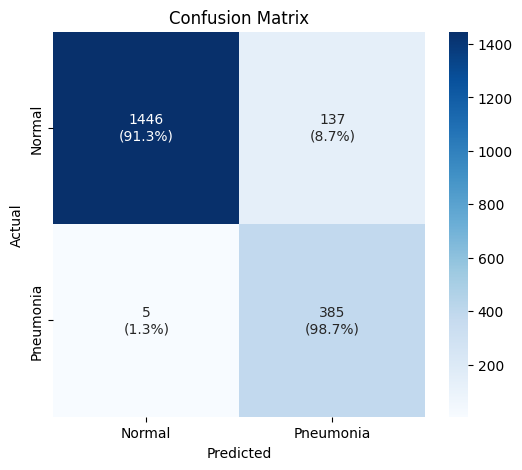


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1583
           1       0.74      0.99      0.84       390

    accuracy                           0.93      1973
   macro avg       0.87      0.95      0.90      1973
weighted avg       0.95      0.93      0.93      1973



In [9]:
print(f"Rechargement du modèle...")
model_load = models.load_model("best_model_efficientnet_binary.keras")

y_true_recharge = test_gen_binary.classes

y_pred_probs_recharge = model_load.predict(test_gen_binary)
y_pred_recharge = (y_pred_probs_recharge > 0.5).astype(int)

print(y_pred_probs_recharge.shape)

plot_roc_curve(y_true, y_pred_probs_recharge, best_threshold)

plot_binary_confusion_matrix(y_true_recharge, y_pred_recharge)

### Trouvé le meilleur **Threshold** 

```
Trouver le meilleur permet d'ajuster les valeurs de la probabilité du modèle
```

62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 459ms/step
Threshold 0.10 | F1: 0.573 | Recall: 0.997 | Precision: 0.402
Threshold 0.15 | F1: 0.634 | Recall: 0.997 | Precision: 0.464
Threshold 0.20 | F1: 0.680 | Recall: 0.997 | Precision: 0.516
Threshold 0.25 | F1: 0.719 | Recall: 0.995 | Precision: 0.562
Threshold 0.30 | F1: 0.753 | Recall: 0.990 | Precision: 0.608
Threshold 0.35 | F1: 0.779 | Recall: 0.990 | Precision: 0.642
Threshold 0.40 | F1: 0.807 | Recall: 0.990 | Precision: 0.681
Threshold 0.45 | F1: 0.827 | Recall: 0.990 | Precision: 0.711
Threshold 0.50 | F1: 0.844 | Recall: 0.987 | Precision: 0.738
Threshold 0.55 | F1: 0.857 | Recall: 0.985 | Precision: 0.759
Threshold 0.60 | F1: 0.868 | Recall: 0.982 | Precision: 0.778
Threshold 0.65 | F1: 0.882 | Recall: 0.979 | Precision: 0.803
Threshold 0.70 | F1: 0.893 | Recall: 0.977 | Precision: 0.823
Threshold 0.75 | F1: 0.899 | Recall: 0.972 | Precision: 0.837
Threshold 0.80 | F1: 0.906 | Recall: 0.962 | Precision: 0.856
Threshold 0.85 | F1: 0.916 |

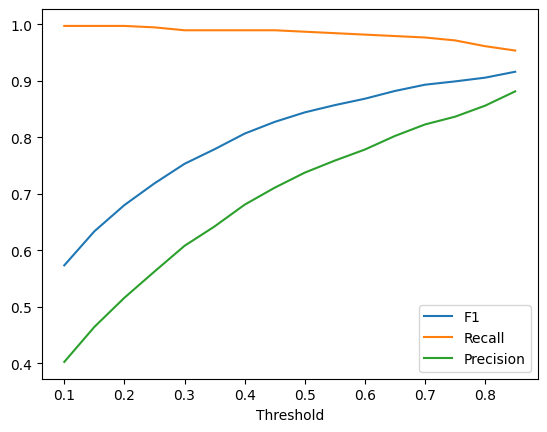

In [10]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score
import matplotlib.pyplot as plt


y_probs = model.predict(test_gen_binary)
y_probs = y_probs.ravel()  # flatten
y_true = test_gen_binary.classes

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    
    f1 = f1_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    
    results.append((t, f1, recall, precision))

for r in results:
    print(f"Threshold {r[0]:.2f} | F1: {r[1]:.3f} | Recall: {r[2]:.3f} | Precision: {r[3]:.3f}")


f1_scores = [r[1] for r in results]
recalls = [r[2] for r in results]
precisions = [r[3] for r in results]

plt.plot(thresholds, f1_scores, label="F1")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.show()